In [ ]:
%matplotlib ipympl

from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import circ_bin_average

import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

unit_id = "107b"

sleep           = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
angle           = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes.npz")
pupil           = nap.load_file(PROCESSED_DATA_PATH / unit_id / "pupil_nrem_normalized.npz")
turn_spikes     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "turn_spikes.npz")

In [2]:
from replay_trajectory_classification import (
    SortedSpikesClassifier,
    Environment,
    RandomWalk,
    Uniform,
    Identity,
    DiagonalDiscrete,
    make_track_graph,
)

def get_environment(num_nodes: int = 360, place_bin_size: float = 1.0):
    radius = 180 / np.pi
    angle = np.linspace(2 * np.pi, 0, num=num_nodes, endpoint=False)
    node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

    node_ids = np.arange(node_positions.shape[0])
    edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

    track_graph = make_track_graph(node_positions, edges)

    n_nodes = len(track_graph.nodes)
    edge_order = np.stack(
        (np.roll(np.arange(n_nodes - 1, -1, -1), 1),
         np.arange(n_nodes - 1, -1, -1)),
        axis=1,
    )

    return Environment(
        place_bin_size=place_bin_size,
        track_graph=track_graph,
        edge_order=edge_order,
        edge_spacing=0,
    )

def fit_classifier(
    hd_spikes,
    hd_angle,
    train_ep: nap.IntervalSet,
    bin_size_ms: int = 1,
    place_bin_size: float = 1.0,
):
    """Fit the classifier on wake training data and return it."""
    spikes = (
        hd_spikes.count(bin_size=bin_size_ms, ep=train_ep, time_units="ms")
        .astype(np.bool_)
    )
    angle = circ_bin_average(tsd=hd_angle, bin_size=bin_size_ms, ep=train_ep, time_units="ms").to_numpy()

    # Build classifier
    environment = get_environment(place_bin_size=place_bin_size)
    continuous_transition_types = [
        [RandomWalk(movement_var=2.0), Uniform(), Identity()],
        [Uniform(),                    Uniform(), Uniform()],
        [RandomWalk(movement_var=2.0), Uniform(), Identity()],
    ]
    classifier = SortedSpikesClassifier(
        environments=environment,
        continuous_transition_types=continuous_transition_types,
        discrete_transition_type=DiagonalDiscrete(STATE_PROB),
    )
    
    # Fit classifier
    classifier.fit(angle, spikes.to_numpy())
    return classifier


In [3]:
environment = get_environment(num_nodes=360, place_bin_size=1.0)

In [4]:
bin_size_ms = 1
train_ep = angle.time_support

spikes = hd_spikes.count(bin_size=bin_size_ms, ep=train_ep, time_units="ms").astype(np.bool_)
hd_angle = angle.bin_average(bin_size=bin_size_ms, ep=train_ep, time_units="ms").to_numpy()

print(spikes.shape, hd_angle.shape)

(6711590, 39) (6711590,)


In [ ]:
STATE_PROB = 0.99
STATE_NAMES = ["continuous", "fragmented", "stationary"]

classifier = fit_classifier(hd_spikes=hd_spikes, hd_angle=angle, train_ep=train_ep, bin_size_ms=bin_size_ms, place_bin_size=1.0,)

In [7]:
sleep[sleep['state'] == 'nrem']
spikes = hd_spikes.count(bin_size=bin_size_ms, ep=sleep[sleep['state'] == 'nrem'][:10], time_units="ms").astype(np.bool_)

In [8]:
decoded = classifier.predict(spikes.values, time=spikes.times(), state_names=STATE_NAMES)

  0%|          | 0/39 [00:00<?, ?it/s]

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\core.py:210: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  discrete_state_transition[state_k, state_k_1]


In [9]:
prob_state = decoded.acausal_posterior.sum(dim="position").to_numpy()
posterior  = decoded.acausal_posterior.sum(dim="state").to_numpy()
t = decoded["time"].to_numpy()

state_p     = pd.DataFrame(prob_state, index=t, columns=STATE_NAMES)
position_p  = pd.DataFrame(posterior, index=t)

In [10]:
state_p.to_csv("D:\\common_datasets\\ucsf\\interim\\107b\\states.csv")
position_p.to_csv("D:\\common_datasets\\ucsf\\interim\\107b\\positions.csv")

In [13]:
state = nap.TsdFrame(pd.read_csv("D:\\common_datasets\\ucsf\\interim\\107b\\states.csv", index_col=0))
position = pd.read_csv("D:\\common_datasets\\ucsf\\interim\\107b\\positions.csv", index_col=0).idxmax(axis=1).astype(np.int16)
position = nap.Tsd(position)

In [22]:
from cmap import Colormap
import matplotlib as mpl

cmaps = ['colorbrewer:RdBu', 'cmocean:phase']
for cmap in cmaps:
    if cmap.lower() not in mpl.colormaps():
        mpl.colormaps.register(Colormap(cmap).to_mpl())

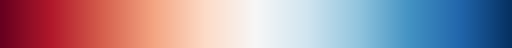

In [8]:
Colormap('colorbrewer:RdBu')

In [ ]:
pref_angle = np.rad2deg(hd_spikes['pref_ang'])
norm = plt.Normalize()

cmap = Colormap('cmocean:phase').to_mpl()
hd_colors = cmap(norm([i / 360 for i in pref_angle.values]))

cmap = Colormap('seaborn:flare').to_mpl()
mod = turn_spikes['cw_modulation'] - turn_spikes['ccw_modulation']

cw_colors = cmap(norm([i for i in mod[cw_mod.keys()].values]))
ccw_colors = cmap(norm([i for i in mod[ccw_mod.keys()].values]))

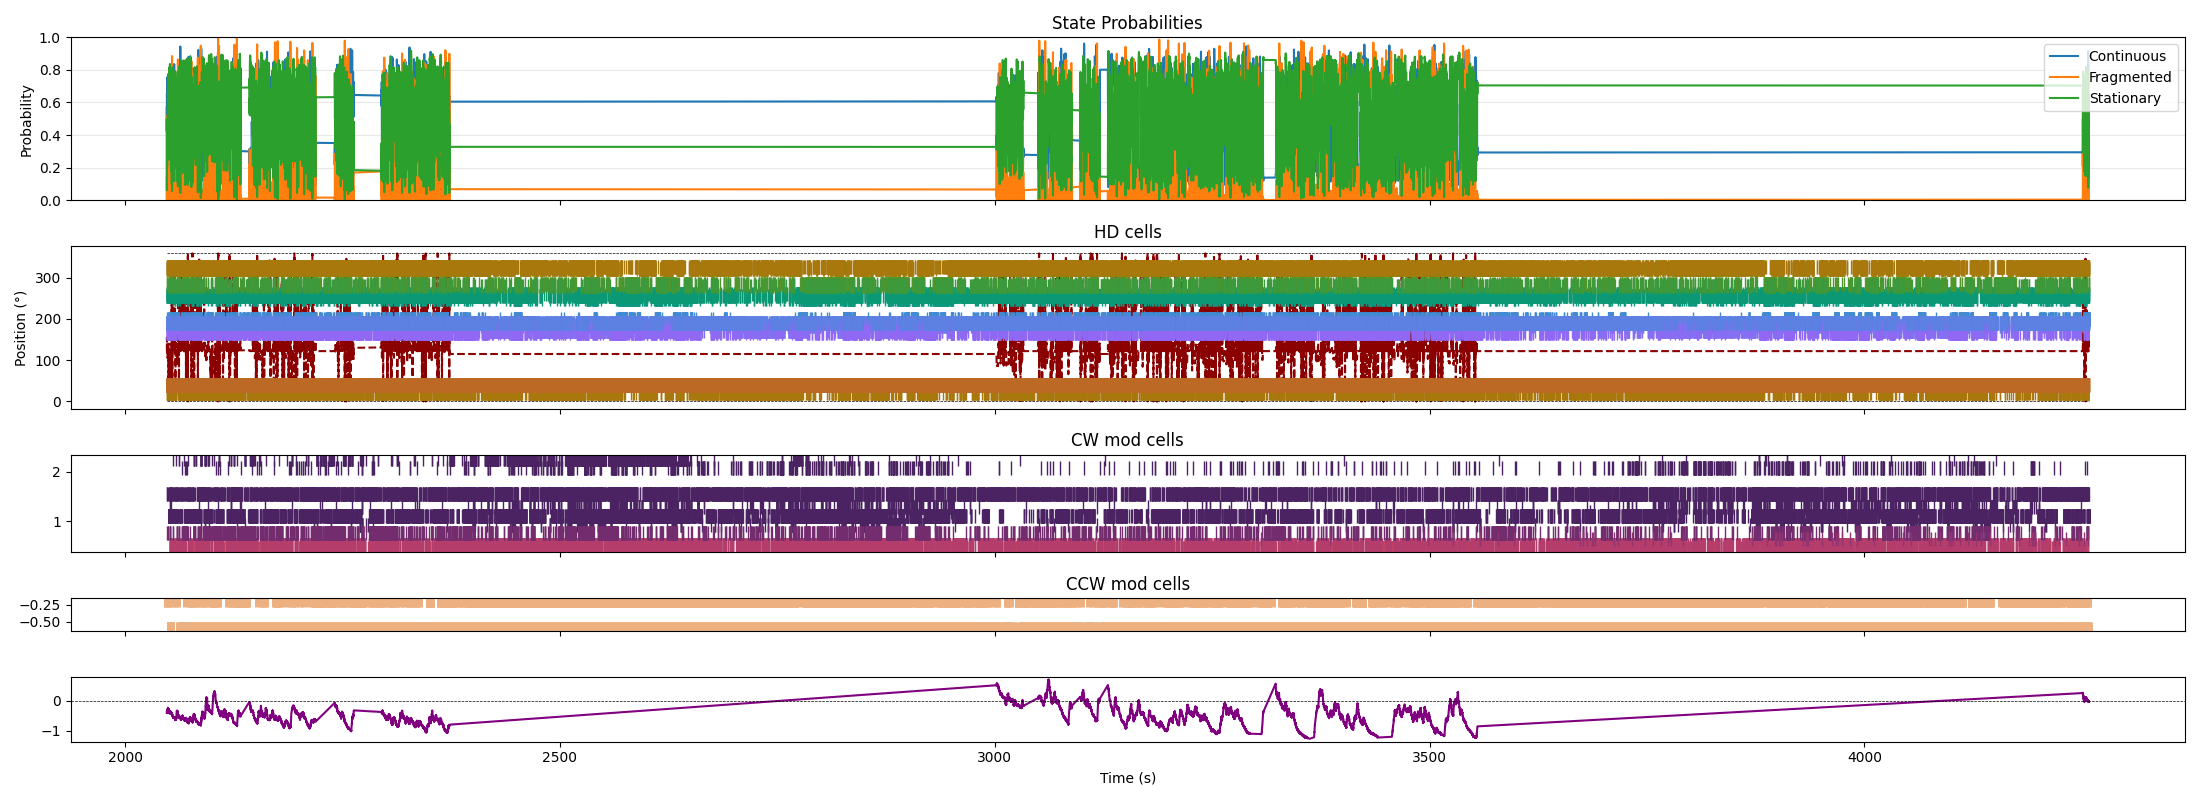

In [58]:
sweep_threshold = 0.5
window = state.time_support
spikes = hd_spikes.restrict(window)
sc = turn_spikes.restrict(window)
cw_mod = sc[mod > 0]
ccw_mod = sc[mod < 0]


fig, ax = plt.subplots(5, 1, figsize=(22, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1, 0.6, 0.2, 0.4]})

# state probabilities
ax[0].plot(state.times(), state['continuous'], label='Continuous', color='tab:blue')
ax[0].plot(state.times(), state['fragmented'], label='Fragmented', color='tab:orange')
ax[0].plot(state.times(), state['stationary'], label='Stationary', color='tab:green')
ax[0].set_ylim(0, 1)
ax[0].set_ylabel('Probability')
ax[0].set_title('State Probabilities')
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

# decoded position + spike raster
ax[1].plot(position, label='Decoded Position', color='#8B0000', alpha=1, linestyle='--')
ax[1].set_ylabel('Position (°)')
ax[1].set_title('HD cells')
ax[1].hlines([0, 359], color='k', xmin=state.times().min(), xmax=state.times().max(), linestyle='--', linewidth=0.5)

for i, n in enumerate(spikes.keys()):
    ax[1].plot(spikes[n].fillna(pref_angle[n].item()), '|', color=hd_colors[i], markersize=10)

# turn spikes
## cw modulated
for i, n in enumerate(cw_mod.keys()):
    ax[2].plot(cw_mod[n].fillna(mod[n].item()), '|', markersize=10, color=cw_colors[i])
ax[2].set_title('CW mod cells')

for i, n in enumerate(ccw_mod.keys()):
    ax[3].plot(ccw_mod[n].fillna(mod[n].item()), '|', markersize=10, markeredgewidth=5, color=ccw_colors[i])
ax[3].set_title('CCW mod cells')

# pupil chord
ax[4].plot(pupil.restrict(window)['pupil_chord'], label='Pupil Chord', color='purple')
ax[4].set_xlabel('Time (s)')
ax[4].axhline(0, color='k', linestyle='--', linewidth=0.5, label='Baseline')

plt.tight_layout()
plt.show()